# Rakyat Speaks — NLP Pipeline
Sentiment classification of Malaysian public opinion on government policies.

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
import nltk
import pickle
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = list(stopwords.words('english'))
print('All imports OK')

All imports OK


## 1. Load Data

In [ ]:
train_df = pd.read_csv('../data/malaysian_sentiment_labeled.csv')
test_df  = pd.read_csv('../data/NLP_Dataset_preparation/gold_labeled.csv')
print(f'Train: {len(train_df)} rows')
print(f'Test (gold): {len(test_df)} rows')
print(f'\nTrain distribution:\n{train_df["sentiment"].value_counts()}')
print(f'\nTest distribution:\n{test_df["human_label"].value_counts()}')

Train: 7383 rows
Test (gold): 402 rows

Train distribution:
sentiment
neutral     5033
negative    2063
positive     287
Name: count, dtype: int64

Test distribution:
human_label
neutral     241
negative    124
positive     37
Name: count, dtype: int64


## 2. Preprocessing

In [5]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    text = re.sub(r'[*_]{1,2}([^*_]+)[*_]{1,2}', r'\1', text)
    text = re.sub(r'^>.*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'&gt;|&amp;|&lt;|&nbsp;', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'[^\w\s!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['cleaned'] = train_df['body'].apply(preprocess)
test_df['cleaned']  = test_df['body'].apply(preprocess)

before = len(train_df)
train_df = train_df[train_df['cleaned'].apply(lambda x: len(x.split())) >= 3].reset_index(drop=True)
print(f'Dropped {before - len(train_df)} short rows from train')
print(f'\nSample before/after preprocessing:')
for i in [0,1,2]:
    print(f'  BEFORE: {train_df["body"].iloc[i][:120]}')
    print(f'  AFTER:  {train_df["cleaned"].iloc[i][:120]}')
    print()

Dropped 208 short rows from train

Sample before/after preprocessing:
  BEFORE: Expats, foreign workers, citizens, PR all contribute to Malaysia via tax.  It is only fair that all social service progr
  AFTER:  expats foreign workers citizens pr all contribute to malaysia via tax it is only fair that all social service program sh

  BEFORE: Nothing special. subsidi bersasar RON95. Bring your IC, 3 months payslip (salaried employee), EPF statement and employme
  AFTER:  nothing special subsidi bersasar ron95 bring your ic 3 months payslip salaried employee epf statement and employment ver

  BEFORE: Driving without licence ?   Well, I wonder how he's going to get his subsidised RM1.99 / litre RON95.
  AFTER:  driving without licence ? well i wonder how he s going to get his subsidised rm1 99 litre ron95



## 3. Feature Extraction — TF-IDF and Bag of Words

In [6]:
X_train = train_df['cleaned']
y_train = train_df['sentiment']
X_test  = test_df['cleaned']
y_test  = test_df['human_label']

tfidf = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,2), max_features=30000, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

bow = CountVectorizer(stop_words=stop_words, ngram_range=(1,2), max_features=30000, min_df=2)
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)
print(f'TF-IDF feature matrix: {X_train_tfidf.shape}')
print(f'BoW feature matrix:    {X_train_bow.shape}')

TF-IDF feature matrix: (7175, 30000)
BoW feature matrix:    (7175, 30000)


## 4. Model Training and Evaluation

In [7]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, vec):
    sample_w = compute_sample_weight('balanced', y_tr)
    try:
        model.fit(X_tr, y_tr, sample_weight=sample_w)
    except TypeError:
        model.fit(X_tr, y_tr)
    preds  = model.predict(X_te)
    acc    = accuracy_score(y_te, preds)
    kappa  = cohen_kappa_score(y_te, preds)
    report = classification_report(y_te, preds, target_names=['negative','neutral','positive'], output_dict=True)
    print('=' * 50)
    print(f'{name}')
    print(f'  Accuracy: {acc*100:.1f}%   Kappa: {kappa:.3f}')
    print(classification_report(y_te, preds, target_names=['negative','neutral','positive']))
    return {'name':name,'model':model,'acc':acc,'kappa':kappa,'preds':preds,'report':report,'vectorizer':vec}

results = []
results.append(evaluate('Naive Bayes + TF-IDF', MultinomialNB(), X_train_tfidf, y_train, X_test_tfidf, y_test, tfidf))
results.append(evaluate('Naive Bayes + BoW', MultinomialNB(), X_train_bow, y_train, X_test_bow, y_test, bow))
results.append(evaluate('Logistic Regression + TF-IDF', LogisticRegression(class_weight='balanced', max_iter=1000), X_train_tfidf, y_train, X_test_tfidf, y_test, tfidf))
results.append(evaluate('Logistic Regression + BoW', LogisticRegression(class_weight='balanced', max_iter=1000), X_train_bow, y_train, X_test_bow, y_test, bow))

Naive Bayes + TF-IDF
  Accuracy: 64.2%   Kappa: 0.373
              precision    recall  f1-score   support

    negative       0.56      0.56      0.56       124
     neutral       0.79      0.70      0.74       241
    positive       0.33      0.57      0.42        37

    accuracy                           0.64       402
   macro avg       0.56      0.61      0.57       402
weighted avg       0.67      0.64      0.65       402

Naive Bayes + BoW
  Accuracy: 61.2%   Kappa: 0.322
              precision    recall  f1-score   support

    negative       0.50      0.59      0.54       124
     neutral       0.76      0.65      0.70       241
    positive       0.32      0.46      0.38        37

    accuracy                           0.61       402
   macro avg       0.53      0.57      0.54       402
weighted avg       0.64      0.61      0.62       402

Logistic Regression + TF-IDF
  Accuracy: 66.9%   Kappa: 0.365
              precision    recall  f1-score   support

    negative    

## 5. Model Comparison

In [8]:
summary = pd.DataFrame([{
    'Model': r['name'],
    'Accuracy': f"{r['acc']*100:.1f}%",
    'Kappa': f"{r['kappa']:.3f}",
    'Neg F1': f"{r['report']['negative']['f1-score']:.3f}",
    'Neu F1': f"{r['report']['neutral']['f1-score']:.3f}",
    'Pos F1': f"{r['report']['positive']['f1-score']:.3f}",
} for r in results])
print(summary.to_string(index=False))

                       Model Accuracy Kappa Neg F1 Neu F1 Pos F1
        Naive Bayes + TF-IDF    64.2% 0.373  0.556  0.738  0.416
           Naive Bayes + BoW    61.2% 0.322  0.543  0.701  0.378
Logistic Regression + TF-IDF    66.9% 0.365  0.571  0.754  0.381
   Logistic Regression + BoW    67.7% 0.354  0.546  0.765  0.386


## 6. Confusion Matrices

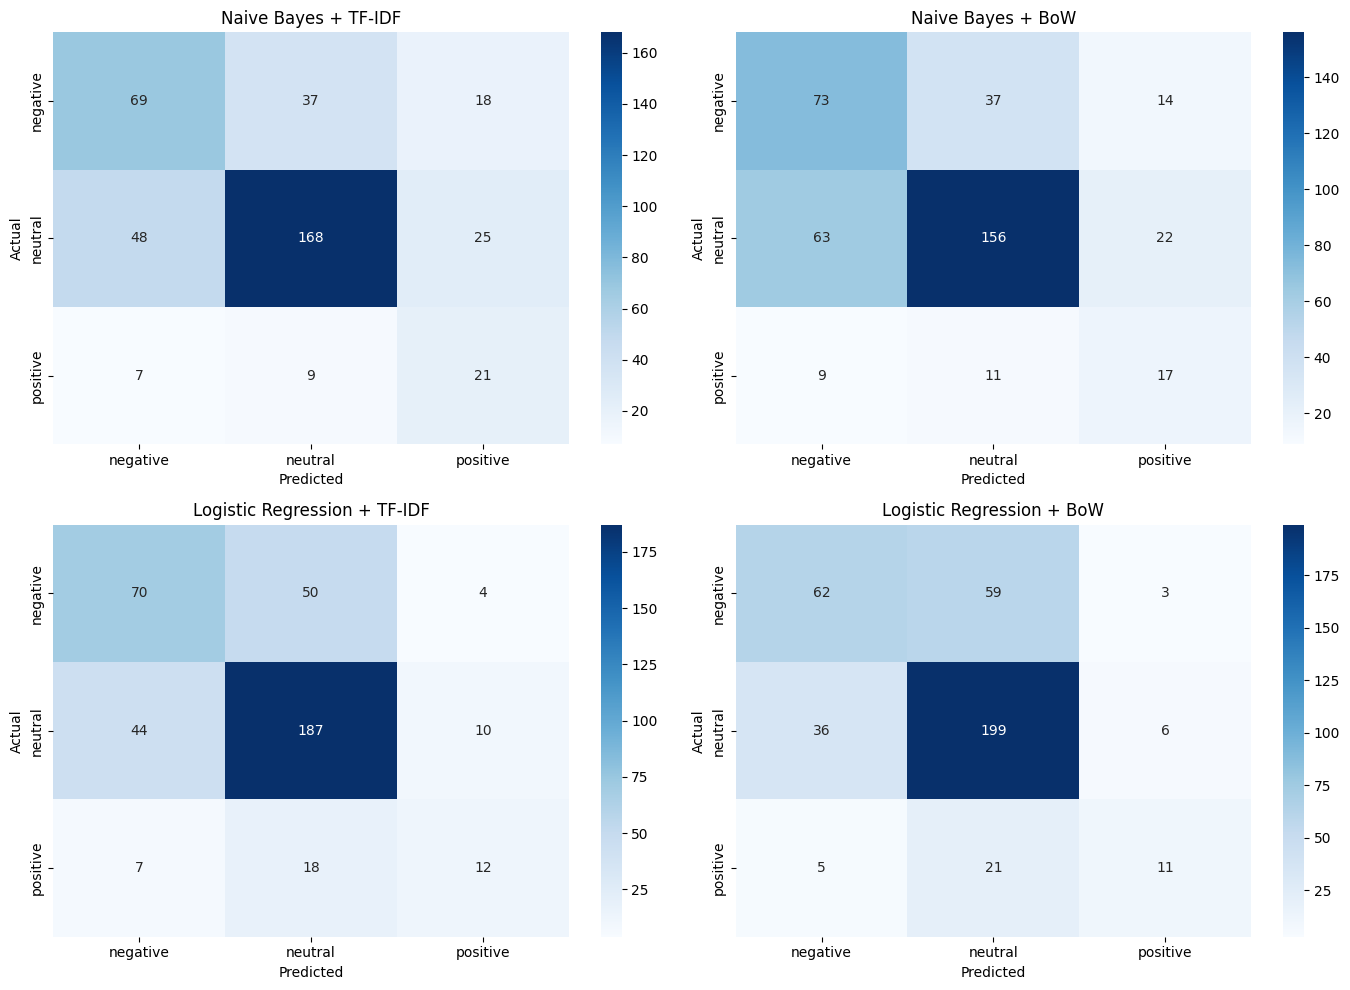

Saved confusion_matrices.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
labels = ['negative','neutral','positive']
for ax, r in zip(axes.flatten(), results):
    cm = confusion_matrix(y_test, r['preds'], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, xticklabels=labels, yticklabels=labels, cmap='Blues')
    ax.set_title(r['name'])
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrices.png')

## 7. Save Best Model

In [10]:
best = max(results, key=lambda r: r['kappa'])
print(f'Best model: {best["name"]}  (kappa={best["kappa"]:.3f}, acc={best["acc"]*100:.1f}%)')
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best['model'], f)
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(best['vectorizer'], f)
print('Saved models/best_model.pkl')
print('Saved models/tfidf_vectorizer.pkl')

Best model: Naive Bayes + TF-IDF  (kappa=0.373, acc=64.2%)
Saved models/best_model.pkl
Saved models/tfidf_vectorizer.pkl
